<a href="https://colab.research.google.com/github/jerrinojacob/Data-Science-Portfolio/blob/main/Project_03/Chinook_Music_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project SQL - Chinook


## Chinook Music Store dataset
This project uses the Chinook dataset to study the data and run queries to understand the data more in depth.

I have used different types of Aggregates, joins, CTEs, created a plot and ask questions and answer them with query.

####**Importing and Setting up the Environment**

In [1]:
#importing for runqueries on sqlite
import sqlite3 as db

#importing for plotting graphs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

####Installing the sqlite package for Ubuntu

In [2]:
# Install the sqlite package for Ubuntu
%%capture
%%bash
apt-get update
apt-get install -y sqlite3

####Loading the Chinook Dataset

In [3]:
%%bash
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -l chinook.zip

Archive:  chinook.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   884736  2015-11-29 10:53   chinook.db
---------                     -------
   884736                     1 file


In [4]:
!rm -f chinook.db

In [5]:
!unzip -u chinook.zip
!ls -lart

Archive:  chinook.zip
  inflating: chinook.db              
total 1180
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db
drwxr-xr-x 4 root root   4096 Oct 22 13:38 .config
drwxr-xr-x 1 root root   4096 Oct 22 13:39 sample_data
drwxr-xr-x 1 root root   4096 Oct 23 17:43 ..
-rw-r--r-- 1 root root 305596 Oct 23 17:44 chinook.zip
drwxr-xr-x 1 root root   4096 Oct 23 17:44 .


####Checking list of tables in Chinook Dataset

In [6]:
%%script sqlite3 --column --header chinook.db
.tables

albums          employees       invoices        playlists     
artists         genres          media_types     tracks        
customers       invoice_items   playlist_track


####Checking Schema of each table of the Chinook Dataset

In [7]:
%%script sqlite3 --column --header chinook.db
.schema

CREATE TABLE IF NOT EXISTS "albums"
(
    [AlbumId] INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
    [Title] NVARCHAR(160)  NOT NULL,
    [ArtistId] INTEGER  NOT NULL,
    FOREIGN KEY ([ArtistId]) REFERENCES "artists" ([ArtistId]) 
		ON DELETE NO ACTION ON UPDATE NO ACTION
);
CREATE TABLE sqlite_sequence(name,seq);
CREATE TABLE IF NOT EXISTS "artists"
(
    [ArtistId] INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
    [Name] NVARCHAR(120)
);
CREATE TABLE IF NOT EXISTS "customers"
(
    [CustomerId] INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
    [FirstName] NVARCHAR(40)  NOT NULL,
    [LastName] NVARCHAR(20)  NOT NULL,
    [Company] NVARCHAR(80),
    [Address] NVARCHAR(70),
    [City] NVARCHAR(40),
    [State] NVARCHAR(40),
    [Country] NVARCHAR(40),
    [PostalCode] NVARCHAR(10),
    [Phone] NVARCHAR(24),
    [Fax] NVARCHAR(24),
    [Email] NVARCHAR(60)  NOT NULL,
    [SupportRepId] INTEGER,
    FOREIGN KEY ([SupportRepId]) REFERENCES "employees" ([EmployeeId]) 
		ON DELETE NO ACTION ON 

###Understanding the Data

####Table: Albums

In [8]:
#Checking the Albums table
%%script sqlite3 --column --header chinook.db
select * from albums limit 5

AlbumId  Title                                  ArtistId
-------  -------------------------------------  --------
1        For Those About To Rock We Salute You  1       
2        Balls to the Wall                      2       
3        Restless and Wild                      2       
4        Let There Be Rock                      1       
5        Big Ones                               3       


In [9]:
#Checking the Albums table
%%script sqlite3 --column --header chinook.db
select count(1) from albums

count(1)
--------
347     


In [10]:
#Checking the Albums table
%%script sqlite3 --column --header chinook.db
select count(distinct Title) from albums

count(distinct Title)
---------------------
347                  


In [11]:
#Checking the Albums table
%%script sqlite3 --column --header chinook.db
select count(Title) from albums
where title is null

count(Title)
------------
0           


Table: "albums"

- [AlbumId] - INTEGER- PK - AUTO-INCREMENT - NOT NULL
- [Title] - NVARCHAR(160) - NOT NULL
- [ArtistId] - INTEGER - FK(artists[ArtistId]) - NOT NULL

Total Events: 347

- Albums contain the Title of the Album and the Artist (key)
- There is unique 347 Titles and no nulls

####Table: Artists

In [12]:
#Checking the Artists table
%%script sqlite3 --column --header chinook.db
select * from artists limit 5

ArtistId  Name             
--------  -----------------
1         AC/DC            
2         Accept           
3         Aerosmith        
4         Alanis Morissette
5         Alice In Chains  


In [13]:
#Checking the Artists table
%%script sqlite3 --column --header chinook.db
select count(1) from Artists

count(1)
--------
275     


In [14]:
#Checking the Artists table
%%script sqlite3 --column --header chinook.db
select count(distinct Name) from Artists

count(distinct Name)
--------------------
275                 


In [15]:
#Checking the Artists table
%%script sqlite3 --column --header chinook.db
select count(name) from artists
where name is null

count(name)
-----------
0          


Table: "artists"

- [ArtistId] - INTEGER- PK - AUTO-INCREMENT - NOT NULL
- [Name] - NVARCHAR(120) - NOT NULL

Total Events: 275

- Albums contain the Name of the Album
- There is unique 275 Names and no nulls

####Table Customers

In [16]:
#Checking the Customers table
%%script sqlite3 --column --header chinook.db
select * from customers limit 5

CustomerId  FirstName  LastName     Company                                           Address                          City                 State  Country         PostalCode  Phone               Fax                 Email                     SupportRepId
----------  ---------  -----------  ------------------------------------------------  -------------------------------  -------------------  -----  --------------  ----------  ------------------  ------------------  ------------------------  ------------
1           Luís       Gonçalves    Embraer - Empresa Brasileira de Aeronáutica S.A.  Av. Brigadeiro Faria Lima, 2170  São José dos Campos  SP     Brazil          12227-000   +55 (12) 3923-5555  +55 (12) 3923-5566  luisg@embraer.com.br      3           
2           Leonie     Köhler                                                         Theodor-Heuss-Straße 34          Stuttgart                   Germany         70174       +49 0711 2842222                        leonekohler@surfeu.de  

In [17]:
#Checking the Customers table
%%script sqlite3 --column --header chinook.db
select count(1) from customers

count(1)
--------
59      


In [18]:
#Checking the Customers table
%%script sqlite3 --column --header chinook.db
select count(distinct FirstName) from customers

count(distinct FirstName)
-------------------------
57                       


In [19]:
#Checking the Customers table
%%script sqlite3 --column --header chinook.db
select count(distinct LastName) from customers

count(distinct LastName)
------------------------
59                      


In [20]:
#Checking the Customers table
%%script sqlite3 --column --header chinook.db
select count(FirstName) from customers
where FirstName is null

count(FirstName)
----------------
0               


Table: "customers"

- [CustomerId] - INTEGER - PK -AUTO-INCREMENT - NOT NULL
- [FirstName] - NVARCHAR(40) - NOT NULL
- [LastName] - NVARCHAR(20) - NOT NULL
- [Company] - NVARCHAR(80)
- [Address] - NVARCHAR(70)
- [City] - NVARCHAR(40)
- [State] - NVARCHAR(40)
- [Country] - NVARCHAR(40)
- [PostalCode] - NVARCHAR(10)
- [Phone] - NVARCHAR(24)
- [Fax] - NVARCHAR(24)
- [Email] - NVARCHAR(60) - NOT NULL
- [SupportRepId] - INTEGER - FK employees([EmployeeId])

Total Events: 59

- Customers table contain the name, address, company name, email and the customer support representative to that customer.
- There is unique 59 unique full names.
- There is a reference to the employees table to the sales representative.


####Table Employees

In [21]:
#Checking the employees table
%%script sqlite3 --column --header chinook.db
select * from employees -- limit 5

EmployeeId  LastName  FirstName  Title                ReportsTo  BirthDate            HireDate             Address                      City        State  Country  PostalCode  Phone              Fax                Email                   
----------  --------  ---------  -------------------  ---------  -------------------  -------------------  ---------------------------  ----------  -----  -------  ----------  -----------------  -----------------  ------------------------
1           Adams     Andrew     General Manager                 1962-02-18 00:00:00  2002-08-14 00:00:00  11120 Jasper Ave NW          Edmonton    AB     Canada   T5K 2N1     +1 (780) 428-9482  +1 (780) 428-3457  andrew@chinookcorp.com  
2           Edwards   Nancy      Sales Manager        1          1958-12-08 00:00:00  2002-05-01 00:00:00  825 8 Ave SW                 Calgary     AB     Canada   T2P 2T3     +1 (403) 262-3443  +1 (403) 262-3322  nancy@chinookcorp.com   
3           Peacock   Jane       Sales Suppo

In [22]:
#Checking the employees table
%%script sqlite3 --column --header chinook.db
select count(1) from employees

count(1)
--------
8       


In [23]:
#Checking the employees table
%%script sqlite3 --column --header chinook.db
select count(distinct FirstName) from employees

count(distinct FirstName)
-------------------------
8                        


In [24]:
#Checking the employees table
%%script sqlite3 --column --header chinook.db
select count(distinct LastName) from employees

count(distinct LastName)
------------------------
8                       


In [25]:
#Checking the employees table
%%script sqlite3 --column --header chinook.db
select count(FirstName) from employees
where FirstName is null

count(FirstName)
----------------
0               


Table: "employees"

- [EmployeeId] - INTEGER - PK -AUTO-INCREMENT - NOT NULL
- [LastName] - NVARCHAR(20) - NOT NULL
- [FirstName] - NVARCHAR(20) - NOT NULL
- [Title] - NVARCHAR(30)
- [ReportsTo] - INTEGER - FK employees([EmployeeId])
- [BirthDate] - DATETIME
- [HireDate] - DATETIME
- [Address] - NVARCHAR(70)
- [City] - NVARCHAR(40)
- [State] - NVARCHAR(40)
- [Country] - NVARCHAR(40)
- [PostalCode] - NVARCHAR(10)
- [Phone] - NVARCHAR(24)
- [Fax] - NVARCHAR(24)
- [Email] - NVARCHAR(60)

Total Events: 8

- Employee table contain the employee name, title, reportng manager, DOB, DOH, residential address, phone#, email
- There is unique 8 unique full names
- Contains a reference to itself - referencing a supervisor of the employee


####Table Genres

In [26]:
#Checking the genres table
%%script sqlite3 --column --header chinook.db
select * from genres -- limit 5

GenreId  Name              
-------  ------------------
1        Rock              
2        Jazz              
3        Metal             
4        Alternative & Punk
5        Rock And Roll     
6        Blues             
7        Latin             
8        Reggae            
9        Pop               
10       Soundtrack        
11       Bossa Nova        
12       Easy Listening    
13       Heavy Metal       
14       R&B/Soul          
15       Electronica/Dance 
16       World             
17       Hip Hop/Rap       
18       Science Fiction   
19       TV Shows          
20       Sci Fi & Fantasy  
21       Drama             
22       Comedy            
23       Alternative       
24       Classical         
25       Opera             


In [27]:
#Checking the genres table
%%script sqlite3 --column --header chinook.db
select count(1) from genres

count(1)
--------
25      


In [28]:
#Checking the genres table
%%script sqlite3 --column --header chinook.db
select count(distinct Name) from genres

count(distinct Name)
--------------------
25                  


In [29]:
#Checking the genres table
%%script sqlite3 --column --header chinook.db
select count(Name) from genres
where Name is null

count(Name)
-----------
0          


Table: genres
- Attributes
  - [GenreId] - INTEGER - PK - AUTO-INCREMENT - NOT NULL
  - [Name] - NVARCHAR(120)

- 25 genres
- No nulls

####Table Invoices

In [30]:
#Checking the invoices table
%%script sqlite3 --column --header chinook.db
select * from invoices limit 5

InvoiceId  CustomerId  InvoiceDate          BillingAddress           BillingCity  BillingState  BillingCountry  BillingPostalCode  Total
---------  ----------  -------------------  -----------------------  -----------  ------------  --------------  -----------------  -----
1          2           2009-01-01 00:00:00  Theodor-Heuss-Straße 34  Stuttgart                  Germany         70174              1.98 
2          4           2009-01-02 00:00:00  Ullevålsveien 14         Oslo                       Norway          0171               3.96 
3          8           2009-01-03 00:00:00  Grétrystraat 63          Brussels                   Belgium         1000               5.94 
4          14          2009-01-06 00:00:00  8210 111 ST NW           Edmonton     AB            Canada          T6G 2C7            8.91 
5          23          2009-01-11 00:00:00  69 Salem Street          Boston       MA            USA             2113               13.86


In [31]:
#Checking the invoices table
%%script sqlite3 --column --header chinook.db
select count(1) from invoices

count(1)
--------
412     


In [32]:
#Checking the invoices table
%%script sqlite3 --column --header chinook.db
select count(distinct InvoiceDate) from invoices

count(distinct InvoiceDate)
---------------------------
354                        


In [33]:
#Checking the invoices table
%%script sqlite3 --column --header chinook.db
select count(distinct Total) from invoices

count(distinct Total)
---------------------
23                   


In [34]:
#Checking the invoices table
%%script sqlite3 --column --header chinook.db
select count(Total) from invoices
where Total is null

count(Total)
------------
0           


Table: "invoices"

- Attributes
  - [InvoiceId] - INTEGER - PK - AUTO-INCREMENT - NOT NULL
  - [CustomerId] - INTEGER - FK "customers"[CustomerId] - NOT NULL
  - [InvoiceDate] DATETIME  NOT NULL
  - [BillingAddress] NVARCHAR(70)
  - [BillingCity] NVARCHAR(40)
  - [BillingState] NVARCHAR(40)
  - [BillingCountry] NVARCHAR(40)
  - [BillingPostalCode] NVARCHAR(10)
  - [Total] NUMERIC(10,2)  NOT NULL

- Total Events: 412
- Contains a reference to customers - referencing a customerid who is purchasing.

####Table Invoice_Items

In [35]:
#Checking the Invoice_Items table
%%script sqlite3 --column --header chinook.db
select * from Invoice_Items limit 5

InvoiceLineId  InvoiceId  TrackId  UnitPrice  Quantity
-------------  ---------  -------  ---------  --------
1              1          2        0.99       1       
2              1          4        0.99       1       
3              2          6        0.99       1       
4              2          8        0.99       1       
5              2          10       0.99       1       


In [36]:
#Checking the Invoice_Items table
%%script sqlite3 --column --header chinook.db
select count(1) from Invoice_Items

count(1)
--------
2240    


In [37]:
#Checking the Invoice_Items table
%%script sqlite3 --column --header chinook.db
select count(distinct UnitPrice) from Invoice_Items

count(distinct UnitPrice)
-------------------------
2                        


In [38]:
#Checking the Invoice_Items table
%%script sqlite3 --column --header chinook.db
select count(distinct quantity) from Invoice_Items

count(distinct quantity)
------------------------
1                       


In [39]:
#Checking the Invoice_Items table
%%script sqlite3 --column --header chinook.db
select count(quantity) from Invoice_Items
where quantity is null

count(quantity)
---------------
0              


Table: "invoices_items"

- Attributes
  - [InvoiceLineId] - INTEGER - PK - AUTO-INCREMENT - NOT NULL
  - [InvoiceId] - INTEGER - FK "invoices"[InvoiceId] - NOT NULL
  - [TrackId] - INTEGER - FK "tracks"[TrackId] - NOT NULL
  - [UnitPrice] - NUMERIC(10,2) - NOT NULL
  - [Quantity] - INTEGER - NOT NULL

- Total Events: 2240
- Contains a reference to invoice - referencing a invoiceId

####Table media_types

In [40]:
#Checking the media_types table
%%script sqlite3 --column --header chinook.db
select * from media_types --limit 5

MediaTypeId  Name                       
-----------  ---------------------------
1            MPEG audio file            
2            Protected AAC audio file   
3            Protected MPEG-4 video file
4            Purchased AAC audio file   
5            AAC audio file             


In [41]:
#Checking the media_types table
%%script sqlite3 --column --header chinook.db
select count(1) from media_types

count(1)
--------
5       


In [42]:
#Checking the media_types table
%%script sqlite3 --column --header chinook.db
select count(distinct Name) from media_types

count(distinct Name)
--------------------
5                   


In [43]:
#Checking the media_types table
%%script sqlite3 --column --header chinook.db
select count(Name) from media_types
where Name is null

count(Name)
-----------
0          


Table: "media_types"

- Attributes
	- [MediaTypeId] - INTEGER - PK - AUTO-INCREMENT - NOT NULL
	- [Name] - NVARCHAR(120)

- Total Events: 5

####Table playlists

In [44]:
#Checking the playlists table
%%script sqlite3 --column --header chinook.db
select * from playlists --limit 5

PlaylistId  Name                      
----------  --------------------------
1           Music                     
2           Movies                    
3           TV Shows                  
4           Audiobooks                
5           90’s Music                
6           Audiobooks                
7           Movies                    
8           Music                     
9           Music Videos              
10          TV Shows                  
11          Brazilian Music           
12          Classical                 
13          Classical 101 - Deep Cuts 
14          Classical 101 - Next Steps
15          Classical 101 - The Basics
16          Grunge                    
17          Heavy Metal Classic       
18          On-The-Go 1               


In [45]:
#Checking the playlists table
%%script sqlite3 --column --header chinook.db
select count(1) from playlists

count(1)
--------
18      


In [46]:
#Checking the playlists table
%%script sqlite3 --column --header chinook.db
select count(distinct Name) from playlists

count(distinct Name)
--------------------
14                  


In [47]:
#Checking the playlists table
%%script sqlite3 --column --header chinook.db
select count(Name) from playlists
where Name is null

count(Name)
-----------
0          


Table: "playlists"

- Attributes
	- [PlaylistId] - INTEGER - PK - AUTO-INCREMENT - NOT NULL
	- [Name] - NVARCHAR(120)

- Total Events: 18

####Table playlist_track

In [48]:
#Checking the playlist_track table
%%script sqlite3 --column --header chinook.db
select * from playlist_track limit 5

PlaylistId  TrackId
----------  -------
1           3402   
1           3389   
1           3390   
1           3391   
1           3392   


In [49]:
#Checking the playlist_track table
%%script sqlite3 --column --header chinook.db
select count(1) from playlist_track

count(1)
--------
8715    


In [50]:
#Checking the playlist_track table
%%script sqlite3 --column --header chinook.db
select count(distinct TrackId) from playlist_track

count(distinct TrackId)
-----------------------
3503                   


In [51]:
#Checking the playlist_track table
%%script sqlite3 --column --header chinook.db
select count(TrackId) from playlist_track
where TrackId is null

count(TrackId)
--------------
0             


Table: "playlist_track"

- Attributes
	- [PlaylistId] - INTEGER - PK - FK "playlists"[PlaylistId] - NOT NULL
	- [TrackId] - INTEGER - PK - FK "tracks"[TrackId] - NOT NULL

- Total Events: 8715

####Table tracks

In [52]:
#Checking the tracks table
%%script sqlite3 --column --header chinook.db
select * from tracks limit 5

TrackId  Name                                     AlbumId  MediaTypeId  GenreId  Composer                                                                Milliseconds  Bytes     UnitPrice
-------  ---------------------------------------  -------  -----------  -------  ----------------------------------------------------------------------  ------------  --------  ---------
1        For Those About To Rock (We Salute You)  1        1            1        Angus Young, Malcolm Young, Brian Johnson                               343719        11170334  0.99     
2        Balls to the Wall                        2        2            1                                                                                342562        5510424   0.99     
3        Fast As a Shark                          3        2            1        F. Baltes, S. Kaufman, U. Dirkscneider & W. Hoffman                     230619        3990994   0.99     
4        Restless and Wild                        3        2     

In [53]:
#Checking the tracks table
%%script sqlite3 --column --header chinook.db
select count(1) from tracks

count(1)
--------
3503    


In [54]:
#Checking the playlist_trackstrack table
%%script sqlite3 --column --header chinook.db
select count(distinct TrackId) from tracks

count(distinct TrackId)
-----------------------
3503                   


In [55]:
#Checking the tracks table
%%script sqlite3 --column --header chinook.db
select count(TrackId) from tracks
where TrackId is null

count(TrackId)
--------------
0             


Table: "track"

- Attributes
	- [TrackId] - INTEGER - PK - AUTO-INCREMENT - NOT NULL
	- [Name] NVARCHAR(200) - NOT NULL
	- [AlbumId] INTEGER - FK "albums"[AlbumId]
	- [MediaTypeId] INTEGER - FK "media_types"[MediaTypeId] - NOT NULL
	- [GenreId] INTEGER - FK "genres"[GenreId]
	- [Composer] NVARCHAR(220)
	- [Milliseconds] INTEGER  NOT NULL
	- [Bytes] INTEGER
	- [UnitPrice] NUMERIC(10,2)  NOT NULL

- Total Events: 3503

####ERD Diagram
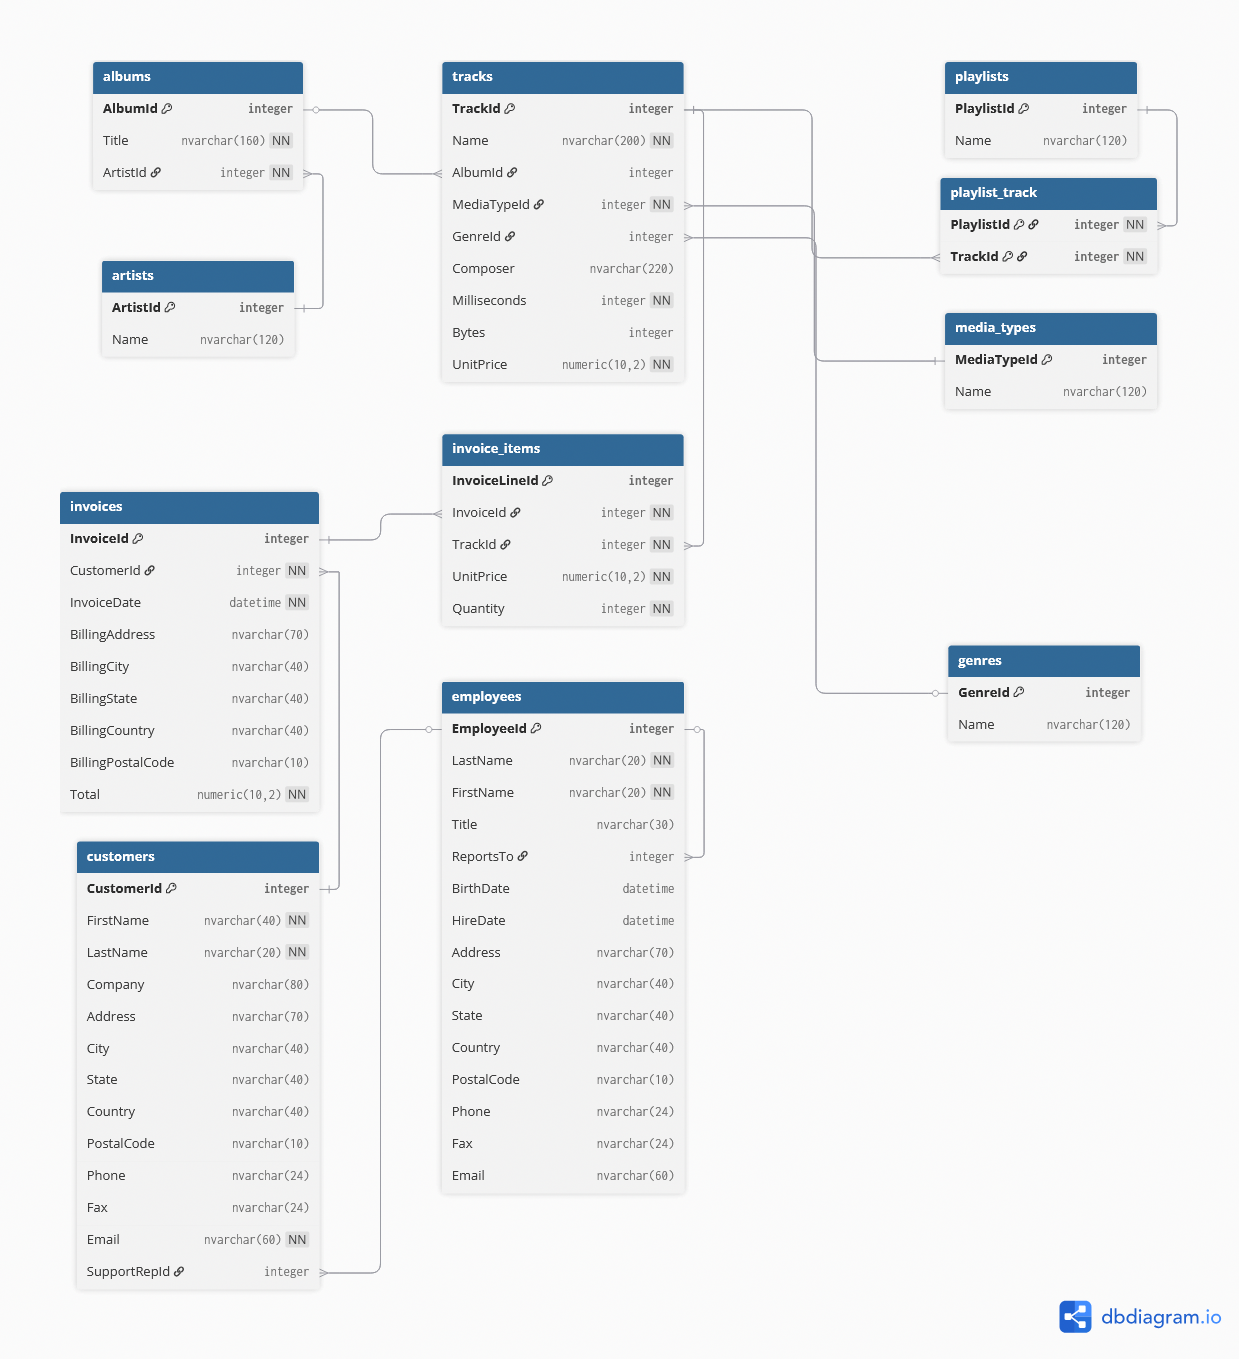

## Basic Queries


### WHERE


In [56]:
%%script sqlite3 --column --header chinook.db
/*
# Using WHERE Clause
*/
SELECT Title
FROM Albums
WHERE Title = 'Balls to the Wall'

Title            
-----------------
Balls to the Wall


#### AND


In [57]:
%%script sqlite3 --column --header chinook.db
/*
# Using WHERE Clause
# Using AND operator
*/
SELECT AlbumId, Title
FROM Albums
WHERE Title = 'Balls to the Wall' and AlbumId = 2

AlbumId  Title            
-------  -----------------
2        Balls to the Wall


#### OR


In [58]:
%%script sqlite3 --column --header chinook.db
/*
# Using WHERE Clause
# Using IN operator
# Using OR operator
*/
SELECT AlbumId, Title
FROM Albums
WHERE Title IN ('Balls to the Wall','For Those About To Rock We Salute You') OR AlbumId = 12

AlbumId  Title                                
-------  -------------------------------------
1        For Those About To Rock We Salute You
2        Balls to the Wall                    
12       BackBeat Soundtrack                  


#### LIKE (with % or _ wildcard)


In [59]:
%%script sqlite3 --column --header chinook.db
/*
# Using WHERE Clause
# Using LIKE operator with % & _ wildcards
# Using OR operator
*/
SELECT AlbumId, Title
FROM Albums
WHERE Title LIKE 'Balls%Wall' OR Title LIKE '____Those About To Rock We Salute You'

AlbumId  Title                                
-------  -------------------------------------
1        For Those About To Rock We Salute You
2        Balls to the Wall                    


#### BETWEEN


In [60]:
%%script sqlite3 --column --header chinook.db
/*
# Using WHERE Clause
# Using BETWEEN operator
*/
SELECT FirstName, HireDate
FROM Employees --LIMIT 3
WHERE HireDate between '2002-08-01 00:00:00' and '2005-12-01 00:00:00'

FirstName  HireDate           
---------  -------------------
Andrew     2002-08-14 00:00:00
Margaret   2003-05-03 00:00:00
Steve      2003-10-17 00:00:00
Michael    2003-10-17 00:00:00
Robert     2004-01-02 00:00:00
Laura      2004-03-04 00:00:00


#### LIMIT



In [61]:
%%script sqlite3 --column --header chinook.db
/*
# Using WHERE Clause
# Using LIMIT
*/
SELECT Title
FROM Albums
LIMIT 5

Title                                
-------------------------------------
For Those About To Rock We Salute You
Balls to the Wall                    
Restless and Wild                    
Let There Be Rock                    
Big Ones                             


### Sorting and Grouping


#### ORDER BY


In [62]:
%%script sqlite3 --column --header chinook.db
/*
# Using ORDER BY Clause
*/
SELECT AlbumID, Title
FROM Albums
ORDER BY Title

AlbumId  Title                                                                                          
-------  -----------------------------------------------------------------------------------------------
156      ...And Justice For All                                                                         
257      20th Century Masters - The Millennium Collection: The Best of Scorpions                        
296      A Copland Celebration, Vol. I                                                                  
94       A Matter of Life and Death                                                                     
95       A Real Dead One                                                                                
96       A Real Live One                                                                                
285      A Soprano Inspired                                                                             
139      A TempestadeTempestade Ou O Livro Dos Dias    

#### DISTINCT


In [63]:
%%script sqlite3 --column --header chinook.db
/*
# Using DISTINCT
*/
SELECT DISTINCT BillingCountry
FROM Invoices
ORDER BY BillingCountry DESC

BillingCountry
--------------
United Kingdom
USA           
Sweden        
Spain         
Portugal      
Poland        
Norway        
Netherlands   
Italy         
Ireland       
India         
Hungary       
Germany       
France        
Finland       
Denmark       
Czech Republic
Chile         
Canada        
Brazil        
Belgium       
Austria       
Australia     
Argentina     


#### GROUP BY



In [64]:
%%script sqlite3 --column --header chinook.db
/*
# Using GROUP BY Clause
*/
SELECT BillingCountry, '$'||sum(Total) 'Total per Country'
FROM Invoices
GROUP BY BillingCountry
ORDER BY BillingCountry DESC

BillingCountry  Total per Country
--------------  -----------------
United Kingdom  $112.86          
USA             $523.06          
Sweden          $38.62           
Spain           $37.62           
Portugal        $77.24           
Poland          $37.62           
Norway          $39.62           
Netherlands     $40.62           
Italy           $37.62           
Ireland         $45.62           
India           $75.26           
Hungary         $45.62           
Germany         $156.48          
France          $195.1           
Finland         $41.62           
Denmark         $37.62           
Czech Republic  $90.24           
Chile           $46.62           
Canada          $303.96          
Brazil          $190.1           
Belgium         $37.62           
Austria         $42.62           
Australia       $37.62           
Argentina       $37.62           


### Aggregates


#### MAX


In [65]:
%%script sqlite3 --column --header chinook.db
/*
# Using GROUP BY Clause
# Using MAX aggregate
*/
SELECT BillingCountry, '$'||MAX(Total) 'Max per Country'
FROM Invoices --LIMIT 3
GROUP BY BillingCountry
ORDER BY BillingCountry DESC

BillingCountry  Max per Country
--------------  ---------------
United Kingdom  $13.86         
USA             $23.86         
Sweden          $13.86         
Spain           $13.86         
Portugal        $13.86         
Poland          $13.86         
Norway          $15.86         
Netherlands     $13.86         
Italy           $13.86         
Ireland         $21.86         
India           $13.86         
Hungary         $21.86         
Germany         $14.91         
France          $16.86         
Finland         $13.86         
Denmark         $13.86         
Czech Republic  $25.86         
Chile           $17.91         
Canada          $13.86         
Brazil          $13.86         
Belgium         $13.86         
Austria         $18.86         
Australia       $13.86         
Argentina       $13.86         


#### MIN


In [66]:
%%script sqlite3 --column --header chinook.db
/*
# Using GROUP BY Clause
# Using MIN aggregate
*/
SELECT BillingCountry, '$'||MIN(Total) 'Min per Country'
FROM Invoices
GROUP BY BillingCountry
ORDER BY BillingCountry DESC

BillingCountry  Min per Country
--------------  ---------------
United Kingdom  $0.99          
USA             $0.99          
Sweden          $0.99          
Spain           $0.99          
Portugal        $0.99          
Poland          $0.99          
Norway          $0.99          
Netherlands     $0.99          
Italy           $0.99          
Ireland         $0.99          
India           $1.98          
Hungary         $0.99          
Germany         $0.99          
France          $0.99          
Finland         $0.99          
Denmark         $0.99          
Czech Republic  $0.99          
Chile           $0.99          
Canada          $0.99          
Brazil          $0.99          
Belgium         $0.99          
Austria         $0.99          
Australia       $0.99          
Argentina       $0.99          


#### SUM


In [67]:
%%script sqlite3 --column --header chinook.db
/*
# Using GROUP BY Clause
# Using SUM aggregate
*/
SELECT BillingCountry, '$'||Sum(Total) 'Sum per Country'
FROM Invoices
GROUP BY BillingCountry
ORDER BY BillingCountry DESC

BillingCountry  Sum per Country
--------------  ---------------
United Kingdom  $112.86        
USA             $523.06        
Sweden          $38.62         
Spain           $37.62         
Portugal        $77.24         
Poland          $37.62         
Norway          $39.62         
Netherlands     $40.62         
Italy           $37.62         
Ireland         $45.62         
India           $75.26         
Hungary         $45.62         
Germany         $156.48        
France          $195.1         
Finland         $41.62         
Denmark         $37.62         
Czech Republic  $90.24         
Chile           $46.62         
Canada          $303.96        
Brazil          $190.1         
Belgium         $37.62         
Austria         $42.62         
Australia       $37.62         
Argentina       $37.62         


#### AVG


In [68]:
%%script sqlite3 --column --header chinook.db
/*
# Using GROUP BY Clause
# Using AVG aggregate
*/
SELECT BillingCountry, '$'||ROUND(AVG(Total),2) 'Average/Mean per Country'
FROM Invoices
GROUP BY BillingCountry
ORDER BY BillingCountry DESC

BillingCountry  Average/Mean per Country
--------------  ------------------------
United Kingdom  $5.37                   
USA             $5.75                   
Sweden          $5.52                   
Spain           $5.37                   
Portugal        $5.52                   
Poland          $5.37                   
Norway          $5.66                   
Netherlands     $5.8                    
Italy           $5.37                   
Ireland         $6.52                   
India           $5.79                   
Hungary         $6.52                   
Germany         $5.59                   
France          $5.57                   
Finland         $5.95                   
Denmark         $5.37                   
Czech Republic  $6.45                   
Chile           $6.66                   
Canada          $5.43                   
Brazil          $5.43                   
Belgium         $5.37                   
Austria         $6.09                   
Australia       

#### COUNT



In [69]:
%%script sqlite3 --column --header chinook.db
/*
# Using GROUP BY Clause
# Using COUNT aggregate
*/
SELECT BillingCountry, COUNT(Total) 'Count of transations per Country'
FROM Invoices
GROUP BY BillingCountry
ORDER BY BillingCountry DESC

BillingCountry  Count of transations per Country
--------------  --------------------------------
United Kingdom  21                              
USA             91                              
Sweden          7                               
Spain           7                               
Portugal        14                              
Poland          7                               
Norway          7                               
Netherlands     7                               
Italy           7                               
Ireland         7                               
India           13                              
Hungary         7                               
Germany         28                              
France          35                              
Finland         7                               
Denmark         7                               
Czech Republic  14                              
Chile           7                               
Canada          56  

##SQL Queries as per Requirements

###1. Provide a query showing Customers (just their full names, customer ID and country) who are not in the US.

In [70]:
%%script sqlite3 --column --header chinook.db
with
  Customer as (
    SELECT
      LastName
      , FirstName
      , CustomerID
      , Country
    FROM
      customers
  )

SELECT
  (LastName||','||FirstName) as FullName
  , CustomerID
  , Country
FROM
  customer
WHERE
  country not in ('USA')
ORDER BY
  country

FullName               CustomerID  Country       
---------------------  ----------  --------------
Gutiérrez,Diego        56          Argentina     
Taylor,Mark            55          Australia     
Gruber,Astrid          7           Austria       
Peeters,Daan           8           Belgium       
Gonçalves,Luís         1           Brazil        
Martins,Eduardo        10          Brazil        
Rocha,Alexandre        11          Brazil        
Almeida,Roberto        12          Brazil        
Ramos,Fernanda         13          Brazil        
Tremblay,François      3           Canada        
Philips,Mark           14          Canada        
Peterson,Jennifer      15          Canada        
Brown,Robert           29          Canada        
Francis,Edward         30          Canada        
Silk,Martha            31          Canada        
Mitchell,Aaron         32          Canada        
Sullivan,Ellie         33          Canada        
Rojas,Luis             57          Chile         


###2. Provide a query only showing the Customers from Brazil.

In [71]:
%%script sqlite3 --column --header chinook.db
with
  Customer as (
    SELECT
      LastName
      , FirstName
      , CustomerID
      , Country
    FROM
      customers
  )

SELECT
  (LastName||','||FirstName) as FullName
  , Country
FROM
  customer
WHERE
  country in ('Brazil')

FullName         Country
---------------  -------
Gonçalves,Luís   Brazil 
Martins,Eduardo  Brazil 
Rocha,Alexandre  Brazil 
Almeida,Roberto  Brazil 
Ramos,Fernanda   Brazil 


###3. Provide a query showing the Invoices of customers who are from Brazil. The resultant table should show the customer's full name, Invoice ID, Date of the invoice and billing country.

In [72]:
%%script sqlite3 --column --header chinook.db
with
  Customer as (
    SELECT
      LastName
      , FirstName
      , CustomerID
      , Country
    FROM
      customers
    WHERE
      country in ('Brazil')
  ),
  Invoice as (
    SELECT
      InvoiceId
      , CustomerId
      , InvoiceDate
      , BillingCountry
    FROM
      invoices
  )

SELECT
  (LastName||','||FirstName) as FullName
  , InvoiceId
  , InvoiceDate
  , BillingCountry
FROM
  customer as c
    JOIN invoice as i
    ON c.CustomerId = i.CustomerId
ORDER BY
  InvoiceDate
  ,FirstName


FullName         InvoiceId  InvoiceDate          BillingCountry
---------------  ---------  -------------------  --------------
Martins,Eduardo  25         2009-04-09 00:00:00  Brazil        
Almeida,Roberto  34         2009-05-23 00:00:00  Brazil        
Ramos,Fernanda   35         2009-06-05 00:00:00  Brazil        
Rocha,Alexandre  57         2009-09-06 00:00:00  Brazil        
Ramos,Fernanda   58         2009-09-07 00:00:00  Brazil        
Rocha,Alexandre  68         2009-10-17 00:00:00  Brazil        
Ramos,Fernanda   80         2009-12-10 00:00:00  Brazil        
Gonçalves,Luís   98         2010-03-11 00:00:00  Brazil        
Gonçalves,Luís   121        2010-06-13 00:00:00  Brazil        
Rocha,Alexandre  123        2010-06-17 00:00:00  Brazil        
Ramos,Fernanda   132        2010-07-31 00:00:00  Brazil        
Gonçalves,Luís   143        2010-09-15 00:00:00  Brazil        
Martins,Eduardo  154        2010-11-14 00:00:00  Brazil        
Almeida,Roberto  155        2010-11-14 0

###4. Provide a query showing only the Employees who are Sales Agents.

In [73]:
%%script sqlite3 --column --header chinook.db
with
  Employee as (
    SELECT
      LastName
      , FirstName
      , Title
    FROM
      employees
    WHERE
      title in ('Sales Support Agent')
  )

SELECT
  (LastName||','||FirstName) as EmployeeName
  , Title
FROM
  Employee
ORDER BY
  FirstName


EmployeeName   Title              
-------------  -------------------
Peacock,Jane   Sales Support Agent
Park,Margaret  Sales Support Agent
Johnson,Steve  Sales Support Agent


###5. Provide a query showing a unique list of billing countries from the Invoice table.

In [74]:
%%script sqlite3 --column --header chinook.db
with
  Invoice as (
    SELECT
      BillingCountry
    FROM
      invoices
  )

SELECT
  distinct BillingCountry
FROM
  Invoice
ORDER BY
  BillingCountry


BillingCountry
--------------
Argentina     
Australia     
Austria       
Belgium       
Brazil        
Canada        
Chile         
Czech Republic
Denmark       
Finland       
France        
Germany       
Hungary       
India         
Ireland       
Italy         
Netherlands   
Norway        
Poland        
Portugal      
Spain         
Sweden        
USA           
United Kingdom


###7. Provide a query that shows the invoices associated with each sales agent. The resultant table should include the Sales Agent's full name.

In [75]:
%%script sqlite3 --column --header chinook.db
with
  Employee as (
    SELECT
      LastName
      , FirstName
      , EmployeeId
    FROM
      employees
    WHERE
      title in ('Sales Support Agent')
  ),
  Invoice as (
    SELECT
      InvoiceId
      , CustomerId
      , Total
    FROM
      invoices
  ),
  Customer as (
    SELECT
      CustomerID
      , SupportRepId
    FROM
      customers
  )

SELECT
  (LastName||', '||FirstName) as EmployeeName
  , ('$'||ROUND(SUM(Total))) as Total_Sales
FROM
  Employee as e
    JOIN Customer as c
    ON e.EmployeeId = c.SupportRepId
    JOIN Invoice as i
    ON c.CustomerId = i.CustomerId
GROUP BY
  EmployeeName
ORDER BY
  e.FirstName

EmployeeName    Total_Sales
--------------  -----------
Peacock, Jane   $833.0     
Park, Margaret  $775.0     
Johnson, Steve  $720.0     


###8. Provide a query that shows the Invoice Total, Customer name, Country and Sale Agent name for all invoices and customers.

In [76]:
%%script sqlite3 --column --header chinook.db
with
  Employee as (
    SELECT
      LastName
      , FirstName
      , EmployeeId
    FROM
      employees
    WHERE
      title in ('Sales Support Agent')
  ),
  Invoice as (
    SELECT
      InvoiceId
      , CustomerId
      , Total
    FROM
      invoices
  ),
  Customer as (
    SELECT
      LastName
      , FirstName
      , CustomerID
      , Country
      , SupportRepId
    FROM
      customers
  )

SELECT
  (c.LastName||', '||c.FirstName) as CustomerName
  , (e.LastName||', '||e.FirstName) as EmployeeName
  , c.Country
  , ('$'||ROUND(SUM(Total))) as Total_Sales
FROM
  Employee as e
    JOIN Customer as c
    ON e.EmployeeId = c.SupportRepId
    JOIN Invoice as i
    ON c.CustomerId = i.CustomerId
GROUP BY
  EmployeeName
ORDER BY
  e.FirstName

CustomerName     EmployeeName    Country  Total_Sales
---------------  --------------  -------  -----------
Gonçalves, Luís  Peacock, Jane   Brazil   $833.0     
Hansen, Bjørn    Park, Margaret  Norway   $775.0     
Köhler, Leonie   Johnson, Steve  Germany  $720.0     


###9. How many Invoices were there in 2009 and 2011? What are the respective total sales for each of those years?

In [77]:
%%script sqlite3 --column --header chinook.db
with
  Invoice as (
    SELECT
      InvoiceId
      , InvoiceDate
      , Total
    FROM
      invoices
  )

SELECT
  strftime('%Y', InvoiceDate) as Year
  , ('$'||ROUND(SUM(Total))) as Total_Sales
FROM
  Invoice
WHERE
  strftime('%Y', InvoiceDate) IN ('2009', '2011')
GROUP BY
  Year




Year  Total_Sales
----  -----------
2009  $449.0     
2011  $470.0     


###10. Looking at the InvoiceLine table, provide a query that COUNTs the number of line items for Invoice ID 37.

In [78]:
%%script sqlite3 --column --header chinook.db

with
  Invoiceline as (
    SELECT
      InvoiceId
      , count(InvoiceLineId) as InvoiceCounts
    FROM
      Invoice_Items
    WHERE
      InvoiceId = 37
    GROUP BY
      InvoiceId
)

  SELECT
    InvoiceId
    , InvoiceCounts
  FROM
    Invoiceline


InvoiceId  InvoiceCounts
---------  -------------
37         4            


###11. Looking at the InvoiceLine table, provide a query that COUNTs the number of line items for each Invoice. HINT: GROUP BY

In [79]:
%%script sqlite3 --column --header chinook.db

with
  Invoiceline as (
    SELECT
      InvoiceId
      , count(InvoiceLineId) as InvoiceCounts
    FROM
      Invoice_Items
    GROUP BY
      InvoiceId
)

  SELECT
    InvoiceId
    , InvoiceCounts
  FROM
    Invoiceline
  ORDER BY
    InvoiceCounts DESC

InvoiceId  InvoiceCounts
---------  -------------
5          14           
12         14           
19         14           
26         14           
33         14           
40         14           
47         14           
54         14           
61         14           
68         14           
75         14           
82         14           
89         14           
96         14           
103        14           
110        14           
117        14           
124        14           
131        14           
138        14           
145        14           
152        14           
159        14           
166        14           
173        14           
180        14           
187        14           
194        14           
201        14           
208        14           
215        14           
222        14           
229        14           
236        14           
243        14           
250        14           
257        14           
264        14           


###12. Provide a query that includes the track name with each invoice line item.

In [80]:
%%script sqlite3 --column --header chinook.db

with
  Track as (
    SELECT
      TrackId
      , Name
    FROM
      tracks
  ),
  InvoiceLine as(
    SELECT
      TrackId
      , InvoiceLineId
    FROM
      Invoice_Items
  )

SELECT
  InvoiceLineId as Invoice
  , Name as Track_Name
FROM
  track t
    JOIN InvoiceLine i
    ON t.trackId = i.trackId
ORDER BY
  Track_Name


Invoice  Track_Name                                                                                                                 
-------  ---------------------------------------------------------------------------------------------------------------------------
1627     "?"                                                                                                                        
535      #9 Dream                                                                                                                   
1820     'Round Midnight                                                                                                            
874      (Anesthesia) Pulling Teeth                                                                                                 
1005     (White Man) In Hammersmith Palais                                                                                          
696      (Wish I Could) Hideaway                                     

###13. Provide a query that includes the purchased track name AND artist name with each invoice line item.

In [81]:
%%script sqlite3 --column --header chinook.db

with
  Track as (
    SELECT
      TrackId
      , Name
      , AlbumId
    FROM
      tracks
  ),
  InvoiceLine as(
    SELECT
      TrackId
      , InvoiceLineId
    FROM
      Invoice_Items
  ),
  Album as (
    SELECT
      AlbumId
      , ArtistId
    FROM
      Albums
  ),
  Artist as (
    SELECT
      Name
      , ArtistId
    FROM
      Artists
  )

SELECT
  ar.Name as Artist_Name
  , t.Name as Track_Name
  , InvoiceLineId as Invoice
FROM
  track t
    JOIN InvoiceLine i
    ON t.trackId = i.trackId
    JOIN Album a
    ON a.AlbumId = t.AlbumId
    JOIN Artist ar
    ON a.ArtistId = ar.ArtistId
ORDER BY
  Artist_Name
  , Track_Name

Artist_Name                                                                            Track_Name                                                                                                                   Invoice
-------------------------------------------------------------------------------------  ---------------------------------------------------------------------------------------------------------------------------  -------
AC/DC                                                                                  Breaking The Rules                                                                                                           6      
AC/DC                                                                                  Dog Eat Dog                                                                                                                  7      
AC/DC                                                                                  Evil Walks                       

###14. Provide a query that shows the number of invoices per country. HINT: GROUP BY

In [82]:
%%script sqlite3 --column --header chinook.db

with
  Invoice as (
    SELECT
      InvoiceId
      , BillingCountry as Country
    FROM
      Invoices
  )

  SELECT
    Country
    , count(InvoiceId) as InvoiceCounts
  FROM
    Invoice
  Group By
    Country
  Order By
    InvoiceCounts DESC

Country         InvoiceCounts
--------------  -------------
USA             91           
Canada          56           
France          35           
Brazil          35           
Germany         28           
United Kingdom  21           
Portugal        14           
Czech Republic  14           
India           13           
Sweden          7            
Spain           7            
Poland          7            
Norway          7            
Netherlands     7            
Italy           7            
Ireland         7            
Hungary         7            
Finland         7            
Denmark         7            
Chile           7            
Belgium         7            
Austria         7            
Australia       7            
Argentina       7            


###15. Provide a query that shows the total number of tracks in each playlist. The Playlist name should be include on the resultant table.

In [83]:
%%script sqlite3 --column --header chinook.db

with
  Playlist as (
    SELECT
      PlaylistId
      , Name as Playlist_Name
    FROM
      Playlists
  ),
  Playlist_Tracks as (
    SELECT
      PlaylistId
      , TrackId
    FROM
      Playlist_Track
  ),
  Track as (
    SELECT
      TrackId
    from
      Tracks
  )

  SELECT
    Playlist_Name
    , count(t.TrackId) as TrackCount
  FROM
    Track t
      JOIN Playlist_Tracks pt
      ON t.trackId = pt.trackId
      JOIN Playlist p
      ON p.PlaylistId = pt.trackId
  GROUP BY
    Playlist_Name

Playlist_Name               TrackCount
--------------------------  ----------
90’s Music                  4         
Audiobooks                  6         
Brazilian Music             2         
Classical                   2         
Classical 101 - Deep Cuts   2         
Classical 101 - Next Steps  2         
Classical 101 - The Basics  2         
Grunge                      2         
Heavy Metal Classic         2         
Movies                      5         
Music                       5         
Music Videos                2         
On-The-Go 1                 2         
TV Shows                    6         


###16. Provide a query that shows all the Tracks, but displays no IDs. The resultant table should include the Album name, Media type and Genre.

In [84]:
%%script sqlite3 --column --header chinook.db
with/**/
Genre as (
  SELECT
    GenreId
    , Name as GenreName
  FROM
    genres
),
Media  as (
SELECT
  MediaTypeId
  , Name as MediaName
FROM
  media_types
),
Track as (
  SELECT
    TrackId
    , AlbumId
    , MediaTypeId
    , GenreId
    , Name as TrackName
  FROM
    tracks
),
Album as (
SELECT
  AlbumId,
  Title as AlbumName
FROM
  albums
)

SELECT/**/
  GenreName
  , AlbumName
  , TrackName
  , MediaName
FROM
  Album a
    JOIN Track t
    ON a.AlbumId = t.AlbumId
    JOIN Media m
    ON m.MediaTypeId = t.MediaTypeId
    JOIN Genre g
    ON g.GenreId = t.GenreId
ORDER BY
  GenreName

GenreName           AlbumName                                                                                        TrackName                                                                                                                    MediaName                  
------------------  -----------------------------------------------------------------------------------------------  ---------------------------------------------------------------------------------------------------------------------------  ---------------------------
Alternative         Cake: B-Sides and Rarities                                                                       War Pigs                                                                                                                     Purchased AAC audio file   
Alternative         Temple of the Dog                                                                                Say Hello 2 Heaven                                                       

###17. Provide a query that shows all Invoices but includes the \# of invoice line items.

In [85]:
%%script sqlite3 --column --header chinook.db

SELECT
  i.InvoiceID InvoiceNos
  , count(InvoiceLineId) InvoiceLinesCount
FROM
  invoices as i
    join invoice_items as ii
    on i.InvoiceId = ii.InvoiceId
GROUP BY i.InvoiceId
ORDER BY InvoiceLinesCount DESC
/**/

InvoiceNos  InvoiceLinesCount
----------  -----------------
5           14               
12          14               
19          14               
26          14               
33          14               
40          14               
47          14               
54          14               
61          14               
68          14               
75          14               
82          14               
89          14               
96          14               
103         14               
110         14               
117         14               
124         14               
131         14               
138         14               
145         14               
152         14               
159         14               
166         14               
173         14               
180         14               
187         14               
194         14               
201         14               
208         14               
215         14               
222       

## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



In [86]:
# %%script sqlite3 --column --header chinook.db
# with
# a as (
# SELECT BillingCountry Country, Sum(Total) as [Sum per Country]
# FROM Invoices
# GROUP BY BillingCountry
# --ORDER BY Sum(Total)  DESC
# )
# select * from a
# order by [Sum per Country] desc

In [87]:
#Connecting to Chinook Database
conn = db.connect('chinook.db')

In [88]:
#Defining the query in a variable
qry_aggr_sum = """
SELECT BillingCountry Country, Sum(Total) as SumPerCountry
FROM Invoices
GROUP BY BillingCountry
ORDER BY SumPerCountry DESC
"""
qry_aggr_sum

'\nSELECT BillingCountry Country, Sum(Total) as SumPerCountry\nFROM Invoices\nGROUP BY BillingCountry\nORDER BY SumPerCountry DESC\n'

In [89]:
#Moving the Data into a dataframe
df_aggr_sum = pd.read_sql_query(qry_aggr_sum,conn)
df_aggr_sum = df_aggr_sum.head(10)
df_aggr_sum
#.info()

,Country,SumPerCountry
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


In [90]:
#Closing a Connection
conn.close()

In [91]:
#Shape of the df
print("The df Shape: ",df_aggr_sum.shape)
print("The df cols: ",df_aggr_sum.columns)

The df Shape:  (10, 2)
The df cols:  Index(['Country', 'SumPerCountry'], dtype='object')


In [92]:
# #Plotting
# plt.figure(figsize=(12, 6))
# df_aggr_sum.plot(x='Country',y='SumPerCountry',kind='bar', color='Teal', legend=False)
# plt.title('Top 10 Countries by Total Revenue',fontsize=18, fontweight='bold' )
# plt.xlabel('Country', fontsize=12, fontweight='bold')
# plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold');

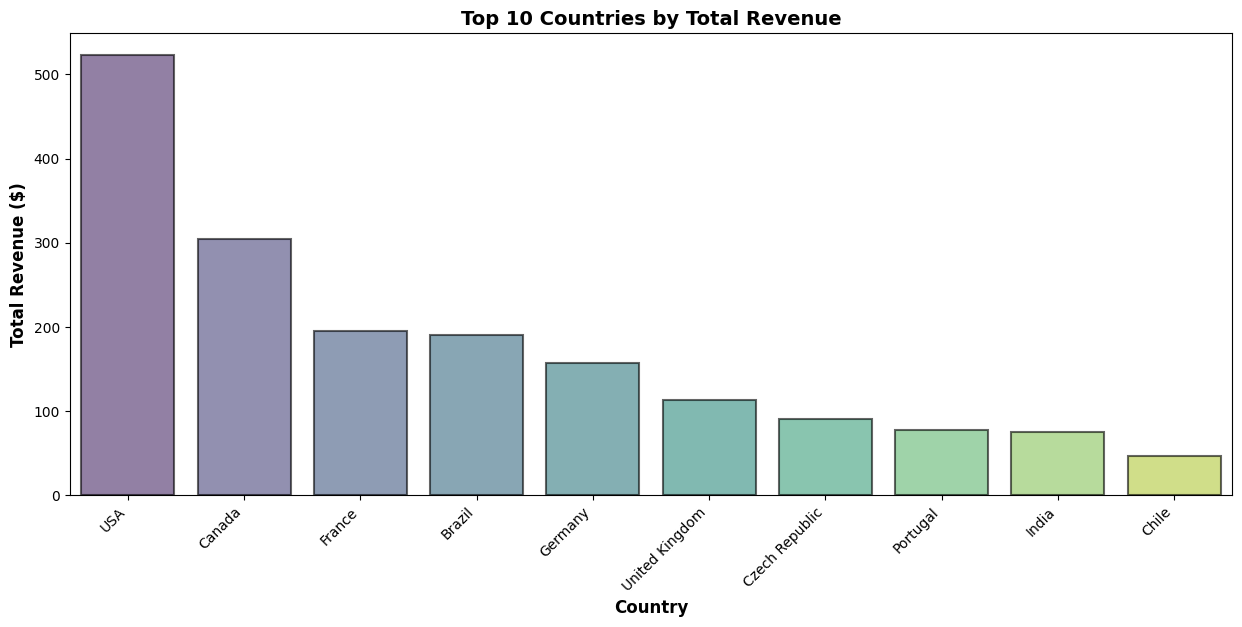

In [93]:
#Plotting
plt.figure(figsize=(15, 6))
sns.barplot(data=df_aggr_sum, x='Country', y='SumPerCountry', hue='Country', palette='viridis', alpha=0.6, edgecolor='black', linewidth=1.5, legend=False)
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right');

##Question \#1

**Business**: What is the productivity of the Sales Team in terms of their Sales.

In [94]:
#Query to generate the sales productivity of each employee
%%script sqlite3 --column --header chinook.db

WITH
  employee as (
    SELECT
      EmployeeId
      , FirstName
      , LastName
    FROM
      employees
  ),
  invoice as (
    SELECT
      InvoiceId
      , CustomerId
      , Total
    FROM
      invoices
  ),
  customer as (
    SELECT
      CustomerId
      , SupportRepId
    FROM
      customers
  )

SELECT
  e.LastName||', '||FirstName as Name
  , '$'||ROUND(COALESCE(SUM(i.Total),0.00),2) AS TotalSales
FROM
  Employee e
    LEFT JOIN customer c
    ON e.EmployeeId = c.SupportRepId
    LEFT JOIN invoice i
    ON c.CustomerId = i.CustomerId
GROUP BY
  e.LastName||', '||FirstName
ORDER BY
  TotalSales DESC

Name               TotalSales
-----------------  ----------
Peacock, Jane      $833.04   
Park, Margaret     $775.4    
Johnson, Steve     $720.16   
Mitchell, Michael  $0.0      
King, Robert       $0.0      
Edwards, Nancy     $0.0      
Callahan, Laura    $0.0      
Adams, Andrew      $0.0      


In [95]:
#Total Sales
%%script sqlite3 --column --header chinook.db
SELECT SUM(Total) TotalSales
FROM Invoices

TotalSales
----------
2328.6    


In [96]:
#Defining the query in a variable
qry_aggr_sum = """
WITH
  employee as (
    SELECT
      EmployeeId
      , FirstName
      , LastName
    FROM
      employees
  ),
  invoice as (
    SELECT
      InvoiceId
      , CustomerId
      , Total
    FROM
      invoices
  ),
  customer as (
    SELECT
      CustomerId
      , SupportRepId
    FROM
      customers
  )

SELECT
  e.LastName||', '||FirstName as Name
  , ROUND(COALESCE(SUM(i.Total),0.00),2) AS TotalSales
FROM
  Employee e
    LEFT JOIN customer c
    ON e.EmployeeId = c.SupportRepId
    LEFT JOIN invoice i
    ON c.CustomerId = i.CustomerId
GROUP BY
  e.LastName||', '||FirstName
ORDER BY
  TotalSales DESC
"""
#qry_aggr_sum

In [97]:
#Connecting to Chinook Database
conn = db.connect('chinook.db')

In [98]:
#Moving the Data into a dataframe
df_q1 = pd.read_sql_query(qry_aggr_sum,conn)
df_q1

,Name,TotalSales
0,"Peacock, Jane",833.04
1,"Park, Margaret",775.40
2,"Johnson, Steve",720.16
3,"Mitchell, Michael",0.00
4,"King, Robert",0.00
5,"Edwards, Nancy",0.00
6,"Callahan, Laura",0.00
7,"Adams, Andrew",0.00


In [99]:
#Closing a Connection
conn.close()

In [100]:
#Shape of the df
print("The df Shape: ",df_q1.shape)
print("The df cols: ",df_q1.columns)

The df Shape:  (8, 2)
The df cols:  Index(['Name', 'TotalSales'], dtype='object')


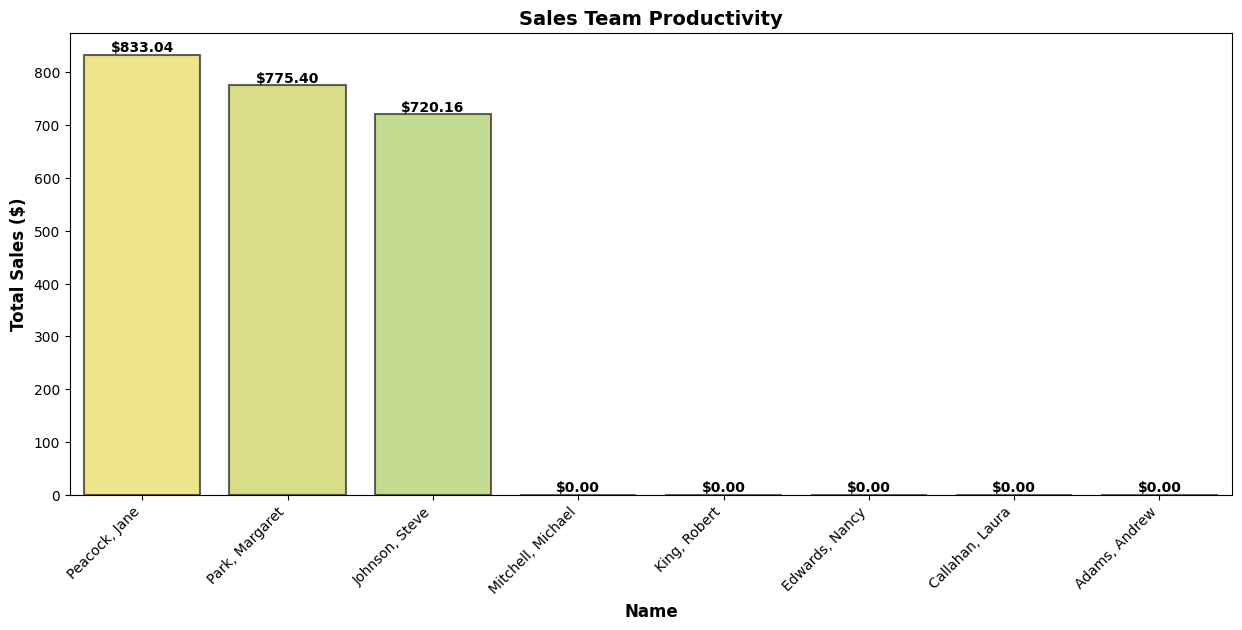

In [101]:
#Plotting
plt.figure(figsize=(15, 6))
# sns.barplot(data=df_q1, x='Name', y='TotalSales', hue='TotalSales', palette='viridis', alpha=0.6, edgecolor='black', linewidth=1.5, legend=False)
ax = sns.barplot(data=df_q1, x='Name', y='TotalSales', hue='TotalSales',
                 palette='viridis', alpha=0.6, edgecolor='black',
                 linewidth=1.5, legend=False)

# Add values on bars
for container in ax.containers:
  ax.bar_label(container, fmt='$%.2f', fontsize=10, fontweight='bold')

plt.xlabel('Name', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.title('Sales Team Productivity', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right');

Response

* Total Sales: \$2,328.60

  - Peacock, Jane	\$833.04
  - Park, Margaret	\$775.40   
  - Johnson, Steve	\$720.16

Top performer is **Ms Jane Peacock**

##Question \#2

**Business**: Which sales rep have the highest average invoice value per customer?

In [102]:
# Query to find the sales metrics of the Sales Reps
%%script sqlite3 --column --header chinook.db

SELECT
    e.SalesRepName
    , COUNT(DISTINCT c.CustomerId) AS TotalCustomers
    , COUNT(DISTINCT i.InvoiceId) AS TotalInvoices
    , '$'||ROUND(COALESCE(SUM(i.Total),0), 2) AS TotalRevenue
    , '$'||ROUND(COALESCE(AVG(i.Total),0), 2) AS AvgInvoiceValue
    , '$'||ROUND(COALESCE(SUM(i.Total) / COUNT(DISTINCT c.CustomerId),0), 2) AS AvgRevenuePerCustomer
FROM
    (
      SELECT  LastName || ', ' || FirstName AS SalesRepName
             , EmployeeId
      FROM    Employees
      WHERE   Title LIKE '%Sales%Support%'
    ) as e
    INNER JOIN
    (
      SELECT  CustomerId
              , SupportRepId
      FROM    Customers
    ) as c
      ON e.EmployeeId = c.SupportRepId
    INNER JOIN
    (
      SELECT  InvoiceId
              , CustomerId
              , Total
      FROM    Invoices
    ) as i
      ON c.CustomerId = i.CustomerId
GROUP BY
    e.EmployeeId
    , e.SalesRepName
ORDER BY
    AvgInvoiceValue DESC;

SalesRepName    TotalCustomers  TotalInvoices  TotalRevenue  AvgInvoiceValue  AvgRevenuePerCustomer
--------------  --------------  -------------  ------------  ---------------  ---------------------
Johnson, Steve  18              126            $720.16       $5.72            $40.01               
Peacock, Jane   21              146            $833.04       $5.71            $39.67               
Park, Margaret  20              140            $775.4        $5.54            $38.77               


Response

* Highest average sales per customer will be **Mr Steve Johnson**
  - He served 18 customers; much lower than other Sales Rep.
  - He sold the music to his customers an average of $40.01  

##Question \#3

**Business**: How many customers have purchased tracks from at least 10 different genres?

In [103]:
# Query to find the sales metrics of the Sales Reps
%%script sqlite3 --column --header chinook.db

SELECT
      c.CustomerName
      , c.Country
      , COUNT(DISTINCT g.GenreId) AS GenreCount
      , COUNT(DISTINCT ii.TrackId) AS TotalTracksPurchased
      , ROUND(SUM(ii.UnitPrice * ii.Quantity), 2) AS TotalSpent
      , GROUP_CONCAT(DISTINCT g.GenreName) AS GenresPurchased
FROM
      (
        SELECT  CustomerId
                , FirstName || ' ' || LastName AS CustomerName
                , Country
        FROM    Customers
      ) as c
        INNER JOIN
      (
        SELECT  InvoiceId
                , CustomerId
        FROM    Invoices
      ) as i
          ON c.CustomerId = i.CustomerId
        INNER JOIN
      (
        SELECT  InvoiceId
                , TrackId
                , Quantity
                , UnitPrice
        FROM    Invoice_Items
      ) as ii
          ON i.InvoiceId = ii.InvoiceId
      INNER JOIN
      (
        SELECT  TrackId
                , GenreId
        FROM    Tracks
      ) as t
          ON ii.TrackId = t.TrackId
      INNER JOIN
      (
      SELECT    GenreId
                , Name as GenreName
      FROM      Genres
      ) as g
        ON t.GenreId = g.GenreId
GROUP BY
      c.CustomerName
      , c.Country
HAVING
      COUNT(DISTINCT g.GenreId) >= 10
ORDER BY
      GenreCount DESC,
      TotalSpent DESC;

CustomerName       Country   GenreCount  TotalTracksPurchased  TotalSpent  GenresPurchased                                                                                                              
-----------------  --------  ----------  --------------------  ----------  -----------------------------------------------------------------------------------------------------------------------------
Luis Rojas         Chile     12          38                    46.62       Rock,Easy Listening,Latin,Soundtrack,Metal,Alternative & Punk,Science Fiction,Sci Fi & Fantasy,Drama,TV Shows,Blues,Classical
Ladislav Kovács    Hungary   11          38                    45.62       Alternative & Punk,Rock,Latin,Metal,Drama,TV Shows,Comedy,Sci Fi & Fantasy,R&B/Soul,Electronica/Dance,Blues                  
Fynn Zimmermann    Germany   10          38                    43.62       Latin,Rock,Alternative & Punk,Easy Listening,Soundtrack,Jazz,Metal,TV Shows,Science Fiction,Drama                        

**Response**:

There are 8 customers who has purchased more than 10 Genres of music from Chinook Music Store

##Question \#4

**Business**: Find customers who have purchased every track from at least one artist

In [104]:
%%script sqlite3 --column --header chinook.db

WITH
/*Count total tracks per artist*/
  ArtistTrack AS (
      SELECT    ar.ArtistId
                , ar.Name AS ArtistName
                , COUNT(DISTINCT t.TrackId) AS TotalTracks
      FROM      Artists ar
                  INNER JOIN Albums a
                  ON ar.ArtistId = a.ArtistId
                  INNER JOIN Tracks t
                  ON a.AlbumId = t.AlbumId
      GROUP BY  ar.ArtistId
                , ar.Name
  ),
/*Count tracks purchased per customer per artist*/
  CustomerArtistPurchases AS (
      SELECT    c.CustomerId
                , c.FirstName || ' ' || c.LastName AS CustomerName
                , ar.ArtistId
                , ar.Name AS ArtistName
                , COUNT(DISTINCT t.TrackId) AS TracksPurchased
      FROM      Customers c
                  INNER JOIN Invoices i
                  ON c.CustomerId = i.CustomerId
                  INNER JOIN Invoice_Items ii
                  ON i.InvoiceId = ii.InvoiceId
                  INNER JOIN Tracks t
                  ON ii.TrackId = t.TrackId
                  INNER JOIN Albums a
                  ON t.AlbumId = a.AlbumId
                  INNER JOIN Artists ar
                  ON a.ArtistId = ar.ArtistId
      GROUP BY  c.CustomerId
                , c.FirstName
                , c.LastName
                , ar.ArtistId
                , ar.Name
  )

SELECT      cap.CustomerName
            , cap.ArtistName
            , cap.TracksPurchased
            , atc.TotalTracks
FROM        CustomerArtistPurchases cap
              INNER JOIN ArtistTrack atc
              ON cap.ArtistId = atc.ArtistId
WHERE     cap.TracksPurchased = atc.TotalTracks
          --and cap.TracksPurchased > 1
ORDER BY  atc.TotalTracks DESC
          , cap.CustomerName

CustomerName        ArtistName                                                                             TracksPurchased  TotalTracks
------------------  -------------------------------------------------------------------------------------  ---------------  -----------
François Tremblay   Michael Tilson Thomas & San Francisco Symphony                                         2                2          
Bjørn Hansen        Royal Philharmonic Orchestra & Sir Thomas Beecham                                      1                1          
Bjørn Hansen        Chicago Symphony Orchestra & Fritz Reiner                                              1                1          
Bjørn Hansen        Edo de Waart & San Francisco Symphony                                                  1                1          
Camille Bernard     Otto Klemperer & Philharmonia Orchestra                                                1                1          
Camille Bernard     Yehudi Menuhin              

Response:

There are 15 customers who has purchased every track from at least one artist.